<a href="https://colab.research.google.com/github/Adityajakhar099/celebal-internship-assignments/blob/main/week4_Aditya_Jakhar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

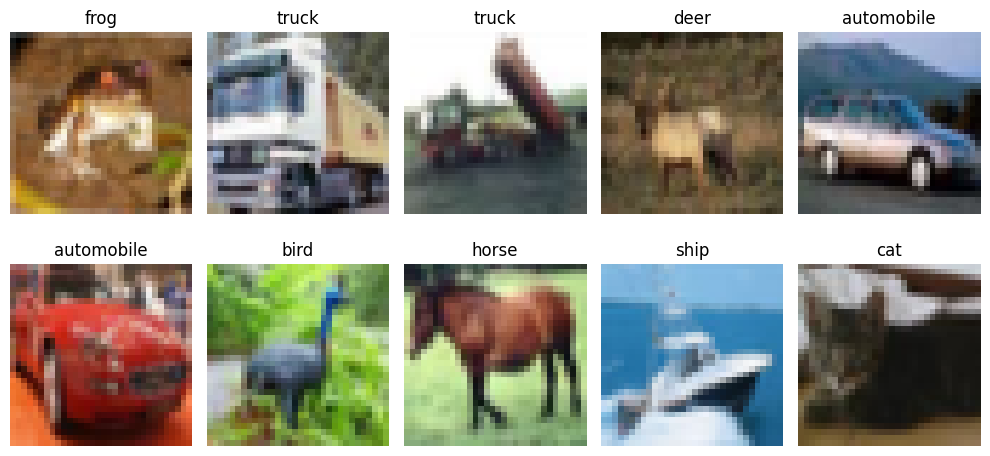

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
# Define the EarlyStopping callback (Task 4)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Your updated ANN model architecture (Task 1)
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    # --- NEW LAYERS ADDED BELOW ---
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    # ------------------------------
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model with updated epochs and callbacks (Tasks 3 & 4)
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,                  # UPDATED: Changed from 10 to 20
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopper]   # ADDED: EarlyStopping callback
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2113 - loss: 2.0817 - val_accuracy: 0.2636 - val_loss: 1.9489
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.2623 - loss: 1.9606 - val_accuracy: 0.3188 - val_loss: 1.8727
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2883 - loss: 1.9097 - val_accuracy: 0.3230 - val_loss: 1.8621
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.2984 - loss: 1.8882 - val_accuracy: 0.3432 - val_loss: 1.8500
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3032 - loss: 1.8761 - val_accuracy: 0.3390 - val_loss: 1.8372
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3096 - loss: 1.8588 - val_accuracy: 0.3408 - val_loss: 1.8342
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3123 - loss: 1.8483 - val_accuracy: 0.3444 - val_loss: 1.8112
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.3152 - loss: 1.8463 - 

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3635 - loss: 1.7678
ANN Test Accuracy: 0.3634999990463257


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
# 1. DEFINE DATA AUGMENTATION FIRST
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# 2. BUILD THE MODEL
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    # --- TASK 2: ADDED 128 FILTER LAYER ---
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    # --------------------------------------

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# 3. COMPILE THE MODEL
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. TRAIN THE MODEL
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,                 # TASK 3: 20 Epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopper]  # TASK 4: Early Stopping
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 90ms/step - accuracy: 0.3401 - loss: 1.7855 - val_accuracy: 0.4494 - val_loss: 1.5038
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.4600 - loss: 1.4899 - val_accuracy: 0.4826 - val_loss: 1.4515
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.5028 - loss: 1.3818 - val_accuracy: 0.5764 - val_loss: 1.1829
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5354 - loss: 1.3039 - val_accuracy: 0.5780 - val_loss: 1.1994
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.5616 - loss: 1.2439 - val_accuracy: 0.5970 - val_loss: 1.1531
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.5823 - loss: 1.1940 - val_accuracy: 0.6434 - val_loss: 1.0182
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5900 - loss: 1.1630 - val_accuracy: 0.6486 - val_loss: 0.9940
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.6066 - loss: 1.1273 - 

In [12]:
cnn_test_loss, cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6897 - loss: 0.8936
CNN Test Accuracy: 0.6897000074386597


## 📈 Compare Learning Curves

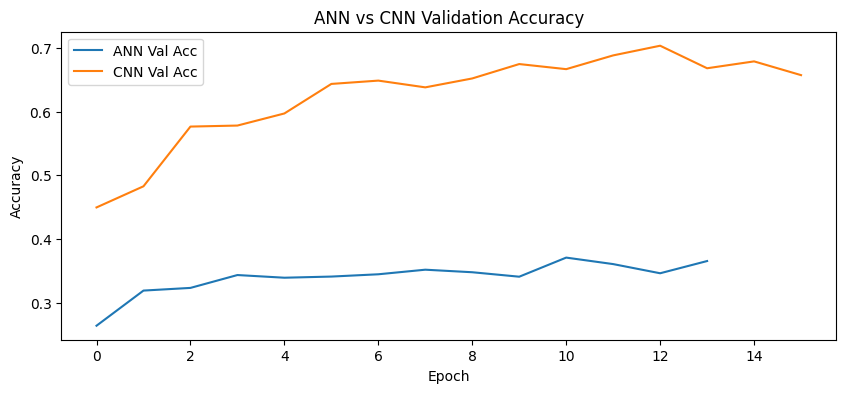

In [14]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    # --- TASK 2: ADDED 128 FILTER LAYER ---
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    # --------------------------------------

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# --- TASKS 3, 4, & 5: UNCOMMENTED AND UPDATED TRAINING ---
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,                 # TASK 3: Changed from 10 to 20
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopper]  # TASK 4: Added EarlyStopping
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - accuracy: 0.3332 - loss: 1.7954 - val_accuracy: 0.4434 - val_loss: 1.5326
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.4543 - loss: 1.5036 - val_accuracy: 0.5242 - val_loss: 1.3218
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5006 - loss: 1.3941 - val_accuracy: 0.5322 - val_loss: 1.3160


# 📊 Final Comparison Table

In [16]:
# First, evaluate your augmented model
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

# Update the table to include all three!
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})

comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4454 - loss: 1.5302


,Model,Test Accuracy
0,ANN,0.3635
1,CNN,0.6897
2,Augmented CNN,0.4454


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**